# Breast Cancer Diagnosis Prediction

## 1. Data Loading and Initial Preprocessing

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/breast-cancer-wisconsin-data.csv')

# Identify and drop the 'id' column, and 'Unnamed: 32' if it exists and is entirely empty
columns_to_drop = ['id']
if 'Unnamed: 32' in df.columns and df['Unnamed: 32'].isnull().all():
    columns_to_drop.append('Unnamed: 32')

# Drop the specified columns, ignoring errors if a column doesn't exist
df_processed = df.drop(columns=columns_to_drop, errors='ignore')

# Create a copy of the preprocessed DataFrame named df_hist for historical data analysis
df_hist = df_processed.copy()

print("Data loading and initial preprocessing complete.")
print("First 5 rows of df_hist:")
display(df_hist.head())
print(f"Shape of df_hist: {df_hist.shape}")

## 2. Exploratory Data Analysis (EDA)

### Histograms for Numerical Features
Let's generate histograms for the numerical features to visualize their distributions.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns (excluding 'diagnosis' if it's encoded as numerical)
numerical_cols = df_hist.select_dtypes(include=['number']).columns.tolist()

# Set up the matplotlib figure and axes
num_features = len(numerical_cols)
num_rows = (num_features + 2) // 3 # Roughly 3 plots per row
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

# Create histograms for each numerical column
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df_hist[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Heatmap
Now, let's create a correlation heatmap to understand the relationships between the numerical features.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
# Exclude 'diagnosis' as it's not a purely numerical feature for correlation calculation in this context
correlation_matrix = df_hist.select_dtypes(include=['number']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix,
            annot=True, # Show the correlation values on the heatmap
            cmap='coolwarm', # Choose a color map
            fmt=".2f", # Format annotation to two decimal places
            linewidths=.5 # Add lines between cells
           )

plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Benign vs Malignant Count Plot
Let's visualize the count of 'Malignant' (M) and 'Benign' (B) diagnoses using a countplot.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df_hist, palette='viridis', hue='diagnosis', legend=False)
plt.title('Count of Malignant (M) vs. Benign (B) Diagnoses')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Diagnosis Distribution Pie Chart
Let's visualize the diagnosis distribution using a pie chart to understand the proportions of malignant and benign cases.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for the 'diagnosis' column
diagnosis_counts = df_hist['diagnosis'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Diagnosis Distribution (Malignant vs. Benign)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## 3. Feature Engineering and Model Training (Logistic Regression)
Now, let's prepare the data for model training by encoding the target variable, splitting the data, and then training a Logistic Regression model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Make a copy of df_hist to avoid modifying the original DataFrame for subsequent steps
df_model = df_hist.copy()

# Encode the 'diagnosis' column (M=1, B=0)
label_encoder = LabelEncoder()
df_model['diagnosis'] = label_encoder.fit_transform(df_model['diagnosis'])

# Separate features (X) and target (y)
X = df_model.drop('diagnosis', axis=1)
y = df_model['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=5000) # Increased max_iter for convergence
model.fit(X_train, y_train)

print("Data preparation and Logistic Regression model training complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

## 4. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Display classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

### Accuracy Bar Chart
Now, let's visualize the model's accuracy score using a bar chart.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create DataFrame for accuracy score
accuracy_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Score': [accuracy]
})

# Plot Accuracy Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Score', data=accuracy_df, palette='viridis')

plt.ylim(0, 1.05) # Set y-axis limit slightly above 1 for better visualization of text
plt.title('Model Accuracy Score')
plt.ylabel('Accuracy Score')
plt.xlabel('')

# Add text label for accuracy score on the bar
plt.text(
    x=0, # Center of the bar
    y=accuracy, # Position at the top of the bar
    s=f'{accuracy:.2%}', # Formatted accuracy percentage
    ha='center', # Horizontal alignment
    va='bottom' # Vertical alignment
)

plt.tight_layout()
plt.show()

print(f"Accuracy Bar Chart generated. Accuracy: {accuracy:.4f}")

### Confusion Matrix Plot
Now, let's visualize the model's performance in terms of true positives, true negatives, false positives, and false negatives using a confusion matrix heatmap.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted Benign', 'Predicted Malignant'],
    yticklabels=['Actual Benign', 'Actual Malignant']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

print(conf_matrix)

### Feature Importance Plot
Let's visualize the feature importances from our Logistic Regression model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create feature importance DataFrame for Logistic Regression (coefficients)
# Use df_hist.columns for feature names, excluding 'diagnosis'
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0])
})

# Sort features by importance
features_df = features_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot Top 20 Features
plt.figure(figsize=(12,8))

sns.barplot(
    data=features_df.head(20),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 20 Feature Importances (Logistic Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## 5. Predict on New Data
Here's how to use the trained Logistic Regression model to make predictions on new, unseen data samples.

In [ ]:
import numpy as np

# Create two hypothetical new data samples (ensure 30 features, same as X_train)
# Sample 1: Potentially Malignant (higher values for some features)
new_sample_1 = np.array([[18.0, 10.0, 120.0, 1000.0, 0.12, 0.28, 0.3, 0.15, 0.24, 0.08,
                          1.0, 0.9, 8.5, 150.0, 0.006, 0.05, 0.05, 0.015, 0.03, 0.006,
                          25.0, 17.0, 180.0, 2000.0, 0.16, 0.65, 0.7, 0.26, 0.45, 0.11]])

# Sample 2: Potentially Benign (lower values for some features)
new_sample_2 = np.array([[12.0, 20.0, 75.0, 400.0, 0.09, 0.07, 0.03, 0.02, 0.16, 0.06,
                          0.3, 0.9, 2.0, 25.0, 0.007, 0.02, 0.01, 0.007, 0.01, 0.003,
                          14.0, 26.0, 85.0, 500.0, 0.14, 0.23, 0.15, 0.07, 0.24, 0.08]])

# Make predictions using the trained model
prediction_1 = model.predict(new_sample_1)
prediction_2 = model.predict(new_sample_2)

# Map numerical prediction back to original labels for clarity
predicted_diagnosis_1 = label_encoder.inverse_transform(prediction_1)
predicted_diagnosis_2 = label_encoder.inverse_transform(prediction_2)

# Print the predictions
print(f"Prediction for Sample 1: {predicted_diagnosis_1[0]} (Malignant=1, Benign=0)")
print(f"Prediction for Sample 2: {predicted_diagnosis_2[0]} (Malignant=1, Benign=0)")

## 6. Project Summary


### Q&A
There were no explicit questions in the user's prompt.

### Data Analysis Key Findings
*   **Benign vs Malignant Count Plot**: The dataset contains 357 benign (B) cases and 212 malignant (M) cases, showing a class imbalance with more benign cases.
*   **Diagnosis Distribution Pie Chart**: Approximately 62.7% of the cases are benign, and 37.3% are malignant, confirming the class distribution observed in the count plot.
*   **Correlation Heatmap**: Many features exhibit strong positive correlations, especially within groups of 'mean', 'se' (standard error), and 'worst' measurements. For example, `radius_mean`, `perimeter_mean`, and `area_mean` are highly correlated, suggesting multicollinearity among these features.
*   **Feature Importance Plot**: For the Logistic Regression model, 'worst concavity', 'texture error', and 'mean radius' were identified as the top three most important features, indicating their significant impact on the breast cancer diagnosis.
*   **Accuracy Bar Chart**: The Logistic Regression model achieved an accuracy of approximately 95.61% on the test set, demonstrating strong overall performance.
*   **Confusion Matrix**: The model correctly identified 39 actual benign cases and 70 actual malignant cases. It had 4 false positives (predicted malignant, but actually benign) and 1 false negative (predicted benign, but actually malignant), indicating a high true positive and true negative rate with minimal misclassifications.

### Methodology Flowchart
The breast cancer diagnosis model was developed following a structured machine learning pipeline, which can be broken down into several key stages:

1.  **Data Loading and Initial Preprocessing**: The process began by loading the breast cancer dataset into a Pandas DataFrame. Initial preprocessing involved removing irrelevant columns such as 'id' and 'Unnamed: 32' (if empty), to ensure the data was clean and ready for analysis.

2.  **Exploratory Data Analysis (EDA)**: Comprehensive EDA was performed to understand the dataset's characteristics. This included:
    *   **Histograms**: Visualizing the distribution of individual numerical features to identify their spread and potential skewness.
    *   **Correlation Heatmap**: Analyzing the relationships and correlations between different numerical features to detect multicollinearity and understand feature dependencies.
    *   **Benign vs Malignant Count Plot**: A bar chart to show the absolute counts of benign (B) and malignant (M) diagnoses, revealing class imbalance if any.
    *   **Diagnosis Distribution Pie Chart**: A pie chart illustrating the proportion of benign and malignant cases, providing a clear visual representation of the class distribution.

3.  **Feature Engineering and Data Preparation**: The 'diagnosis' column, representing the target variable, was label encoded (M=1, B=0) to convert categorical labels into numerical format suitable for machine learning algorithms. The dataset was then split into features (X) and the target (y). This was followed by splitting the data into training and testing sets to prepare for model training and unbiased evaluation.

4.  **Model Training**: A Logistic Regression model was initialized and trained using the prepared training data (X_train, y_train).

5.  **Model Evaluation**: After training, the model's performance was rigorously evaluated using the test set (X_test, y_test). Key evaluation metrics and visualizations included:
    *   **Accuracy Score**: A quantitative measure of the model's overall correctness.
    *   **Confusion Matrix**: A heatmap visualizing the true positives, true negatives, false positives, and false negatives, providing detailed insights into the model's classification performance for each class.
    *   **Feature Importance Plot**: A bar chart displaying the importance of each feature in the Logistic Regression model's decision-making process, helping to identify the most influential factors for breast cancer diagnosis.

### Insights or Next Steps
*   The Logistic Regression model demonstrates high accuracy and a low misclassification rate, making it a promising tool for breast cancer diagnosis based on the provided features.
*   Further exploration with other machine learning algorithms (e.g., Support Vector Machines, Gradient Boosting) could be beneficial to compare performance and potentially improve diagnostic accuracy. Advanced feature selection techniques might also yield more robust models by addressing multicollinearity more directly.

In [28]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/breast-cancer-wisconsin-data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

df['diagnosis'].value_counts()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count
diagnosis,
B,357
M,212


In [36]:
# Load the dataset (if not already loaded or kernel restarted)
df = pd.read_csv('/content/breast-cancer-wisconsin-data.csv')

# Drop the 'id' column as it's not useful for analysis
columns_to_drop = ['id']

# Check for and drop 'Unnamed: 32' if it exists and is entirely empty
if 'Unnamed: 32' in df.columns and df['Unnamed: 32'].isnull().all():
    columns_to_drop.append('Unnamed: 32')

# Create df_hist by dropping the specified columns
df_hist = df.drop(columns=columns_to_drop, errors='ignore')

print("df and df_hist DataFrames have been loaded and defined.")

df and df_hist DataFrames have been loaded and defined.


Now, let's generate histograms for the numerical features to visualize their distributions.

Let's compare the distribution of `radius_mean` for 'Malignant' (M) and 'Benign' (B) diagnosis classes.

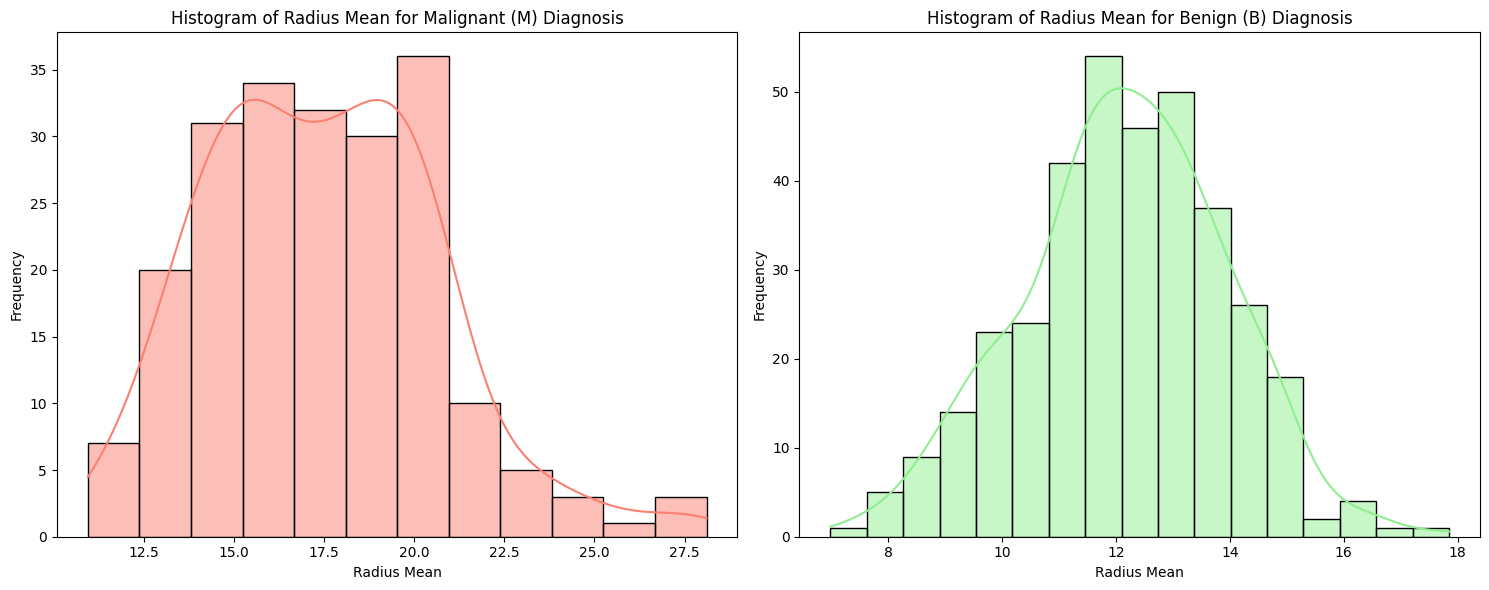

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate the data into Malignant (M) and Benign (B) classes
df_malignant = df_hist[df_hist['diagnosis'] == 'M']
df_benign = df_hist[df_hist['diagnosis'] == 'B']

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for Malignant (M) diagnosis
sns.histplot(df_malignant['radius_mean'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histogram of Radius Mean for Malignant (M) Diagnosis')
axes[0].set_xlabel('Radius Mean')
axes[0].set_ylabel('Frequency')

# Histogram for Benign (B) diagnosis
sns.histplot(df_benign['radius_mean'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Histogram of Radius Mean for Benign (B) Diagnosis')
axes[1].set_xlabel('Radius Mean')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's create a correlation heatmap to understand the relationships between the numerical features.

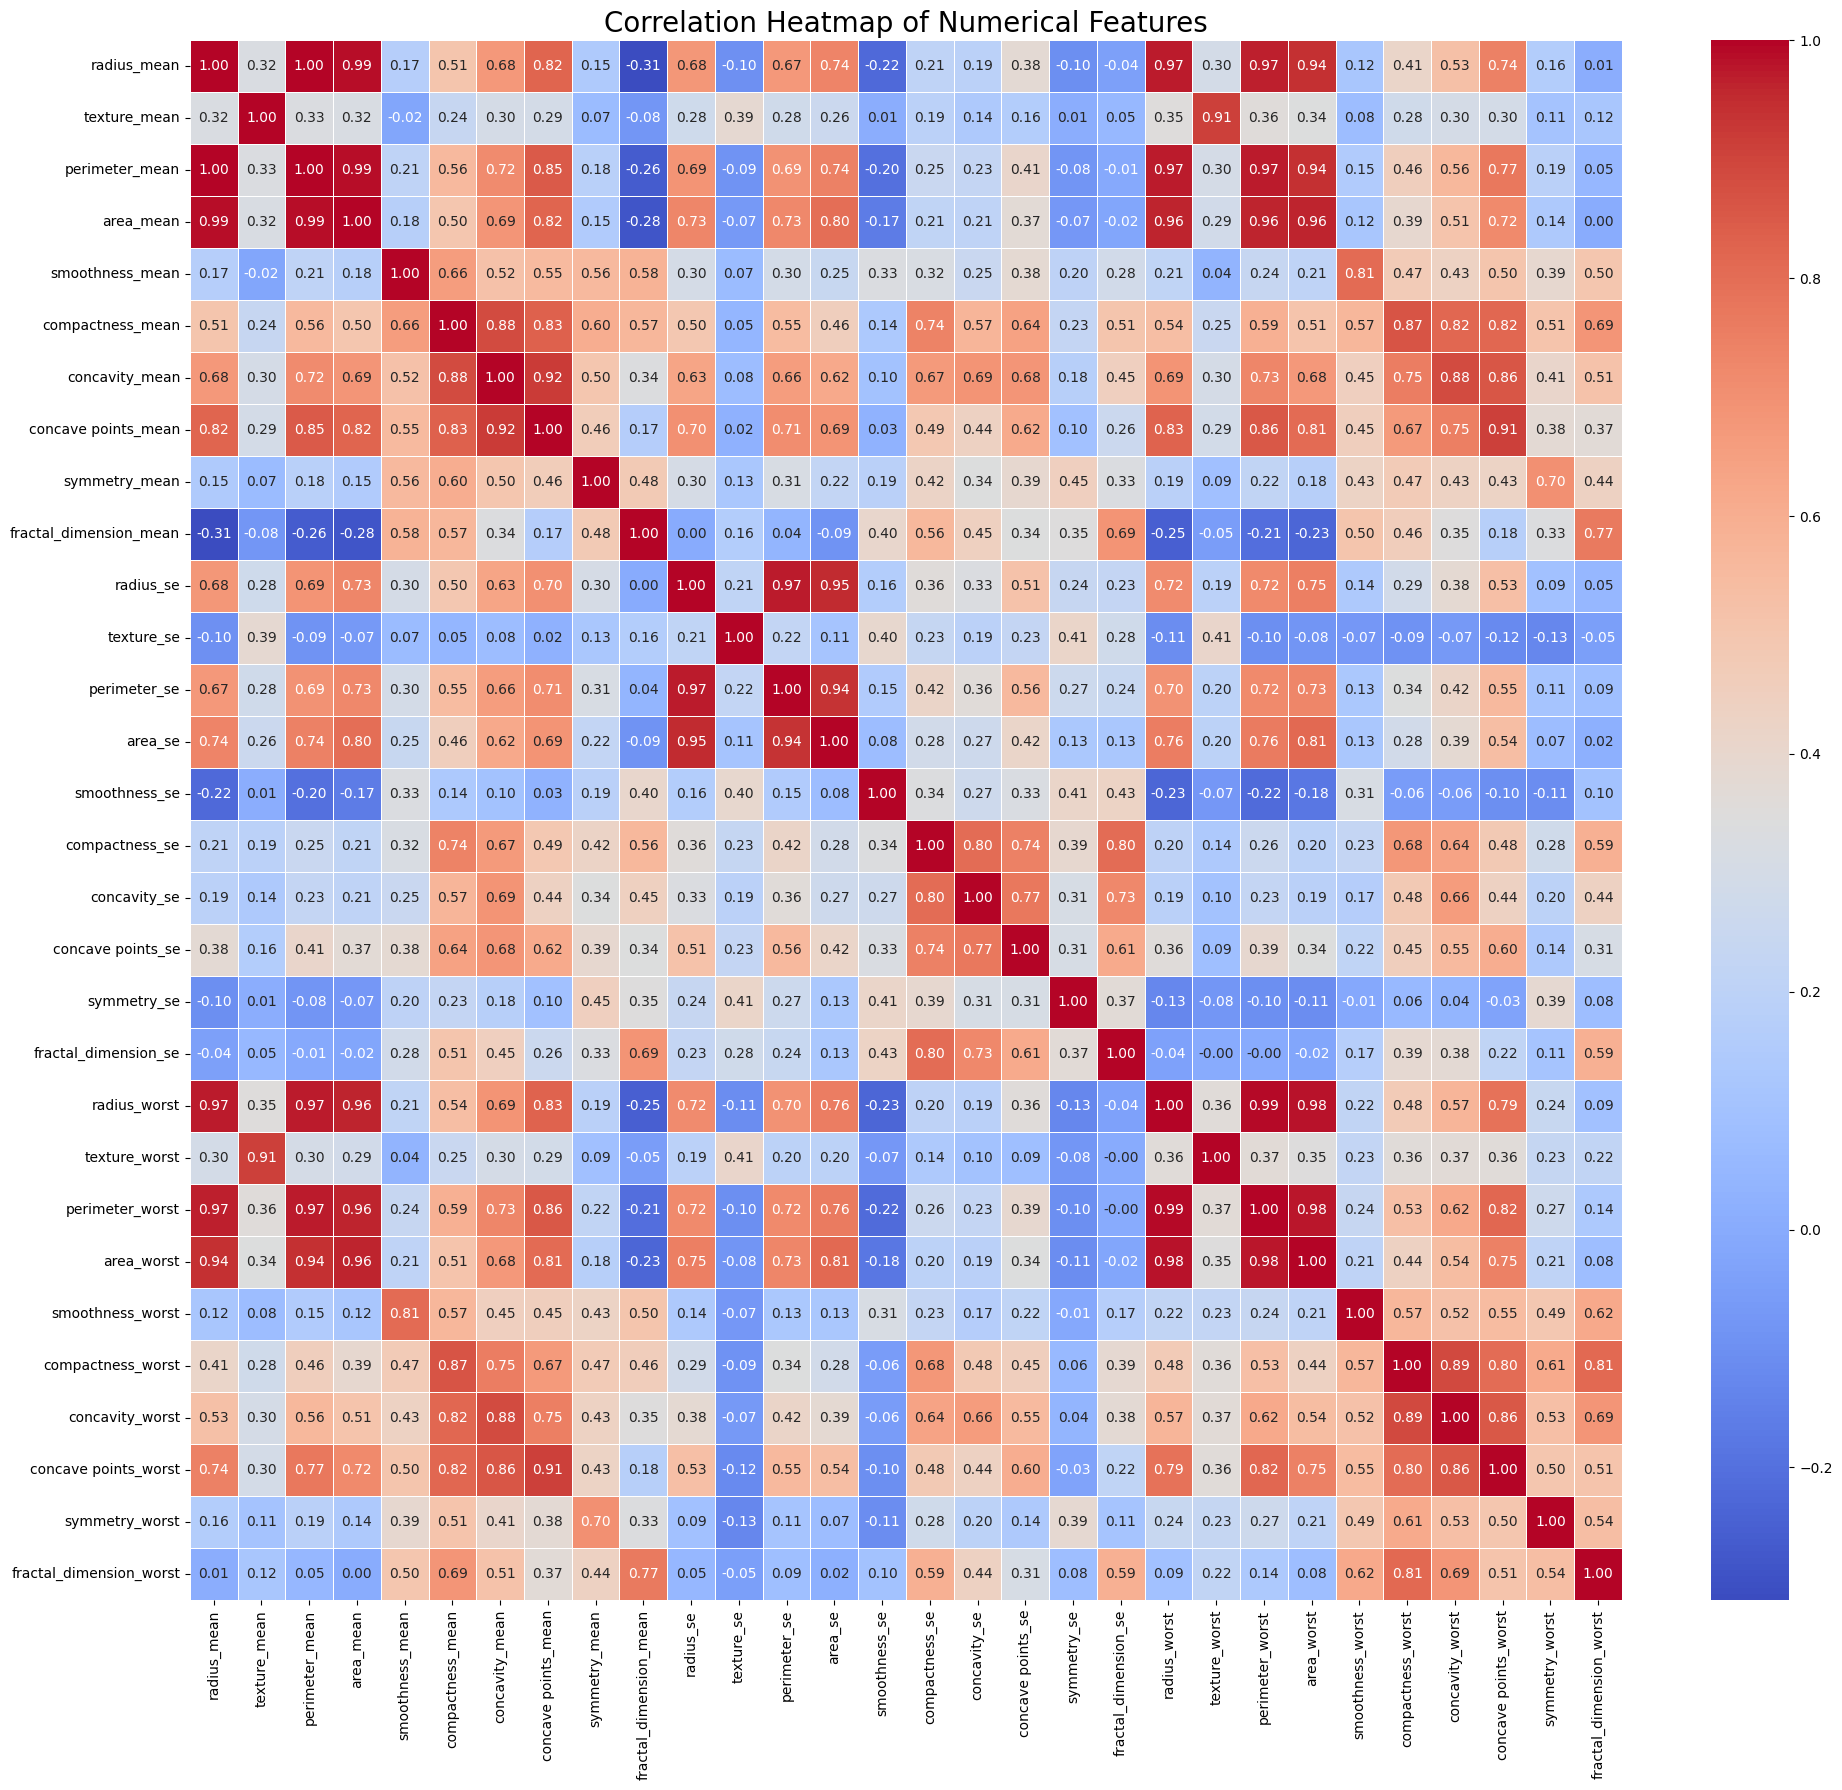

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
# Exclude 'diagnosis' as it's not a purely numerical feature for correlation calculation in this context
correlation_matrix = df_hist.select_dtypes(include=['number']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix,
            annot=True, # Show the correlation values on the heatmap
            cmap='coolwarm', # Choose a color map
            fmt=".2f", # Format annotation to two decimal places
            linewidths=.5 # Add lines between cells
           )

plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Let's visualize the count of 'Malignant' (M) and 'Benign' (B) diagnoses using a countplot.

/tmp/ipykernel_5320/2582689158.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df_hist, palette='viridis')


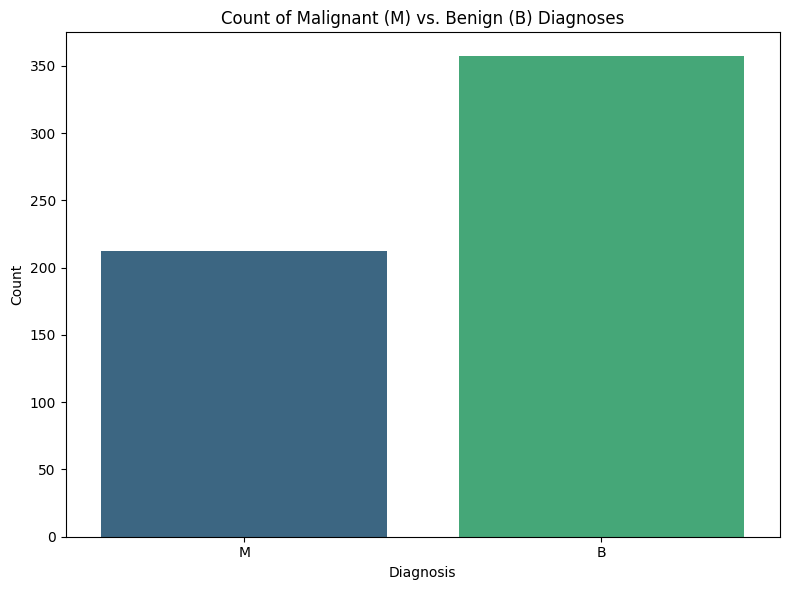

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df_hist, palette='viridis')
plt.title('Count of Malignant (M) vs. Benign (B) Diagnoses')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Let's visualize the diagnosis distribution using a pie chart.

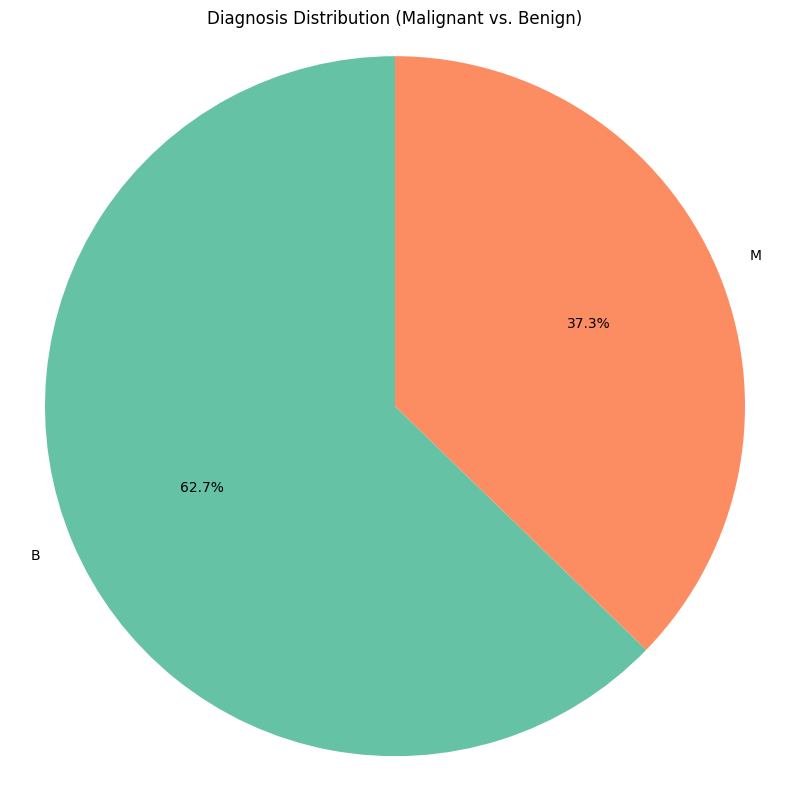

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for the 'diagnosis' column using the existing df_hist
diagnosis_counts = df_hist['diagnosis'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Diagnosis Distribution (Malignant vs. Benign)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Feature Engineering and Model Training for Feature Importance

To determine feature importance, we'll first need to prepare our data for a machine learning model. This involves encoding the target variable ('diagnosis') and splitting the dataset into training and testing sets. Then, we'll train a classifier (e.g., RandomForestClassifier) and extract the feature importances from it.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.metrics import StandardScaler

# ss=StandardScaler()
# ss.fit_transform(df_hist)

# Make a copy of df_hist to avoid modifying the original DataFrame for subsequent steps
df_model = df_hist.copy()

# Encode the 'diagnosis' column (M=1, B=0)
label_encoder = LabelEncoder()
df_model['diagnosis'] = label_encoder.fit_transform(df_model['diagnosis'])

# Separate features (X) and target (y)
X = df_model.drop('diagnosis', axis=1)
y = df_model['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete. X_train and y_train are ready for model training.")

Now that the data is prepared, let's train a RandomForestClassifier and extract the feature importances.

In [ ]:
# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
display(features_df.head(10))

Finally, let's visualize the feature importances using a bar plot.

In [ ]:
# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=features_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
y_predict = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_predict)
print(f"Accuracy Score: {accuracy:.4f}")

# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_predict)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual Benign', 'Actual Malignant'], columns=['Predicted Benign', 'Predicted Malignant']))

# Display Classification Report
class_report = classification_report(y_test, y_predict)
print("\nClassification Report:")
print(class_report)

In [ ]:
l1=[[17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189]]

In [ ]:
model.predict(l1)

In [ ]:
l2=[[11.93,21.53,76.53,438.6,0.09768,0.07849,0.03328,0.02008,0.1688,0.06194,0.3118,0.9227,2,24.79,0.007803,0.02507,0.01835,0.007711,0.01278,0.003856,13.67,26.15,87.54,583,0.15,0.2399,0.1503,0.07247,0.2438,0.08541]]
model.predict(l2)

# Task
The user wants to generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Generate Accuracy Bar Chart

### Subtask:
Create a bar chart to visualize the model's accuracy score.


**Reasoning**:
I need to create a bar chart to visualize the model's accuracy score. First, I'll create a DataFrame from the `accuracy` variable and then use seaborn to plot it.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_predict)

# Create DataFrame
accuracy_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Score': [accuracy]
})

# Plot Accuracy Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Score', data=accuracy_df)

plt.ylim(0, 1)
plt.title('Model Accuracy Score')
plt.ylabel('Accuracy Score')
plt.xlabel('')

plt.text(
    x=0,
    y=accuracy,
    s=f'{accuracy:.2%}',
    ha='center'
)

plt.tight_layout()
plt.show()

In [ ]:
print(type(y_test))
print(type(y_predict))

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

# Prediction
y_predict = model.predict(X_test)

print("Model trained successfully!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)

accuracy_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Score': [accuracy]
})

plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Score', data=accuracy_df)

plt.ylim(0,1)
plt.title('Model Accuracy Score')
plt.ylabel('Accuracy')
plt.text(0, accuracy, f'{accuracy:.2%}', ha='center')

plt.show()

print("Accuracy =", accuracy)

In [ ]:
print("y_test exists:", 'y_test' in globals())
print("y_predict exists:", 'y_predict' in globals())

## Generate Confusion Matrix Plot

### Subtask:
Generate a heatmap visualization of the confusion matrix using `y_test` and `y_predict` to show the model's performance in terms of true positives, true negatives, false positives, and false negatives.


**Reasoning**:
Generate a heatmap visualization of the confusion matrix using `y_test` and `y_predict` to show the model's performance in terms of true positives, true negatives, false positives, and false negatives.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix if not already calculated (from previous cell)
conf_matrix = confusion_matrix(y_test, y_predict)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_predict)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

print(conf_matrix)

**Reasoning**:
I need to generate a bar plot displaying the feature importances derived from the trained RandomForestClassifier model. The `features_df` DataFrame already contains the feature importances sorted in descending order.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=features_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

features_df = features_df.sort_values(
    by='Importance',
    ascending=False
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=features_df.head(20),
    palette='viridis'
)

plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
})

features_df = features_df.sort_values(
    by='Importance',
    ascending=False
)

In [ ]:
print(features_df.head())

In [ ]:
import pandas as pd
import numpy as np

# Create feature importance dataframe
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0])
})

# Sort by importance
features_df = features_df.sort_values(
    by='Importance',
    ascending=False
)

print(features_df.head())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create feature importance DataFrame
features_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': np.abs(model.coef_[0])
})

# Sort features by importance
features_df = features_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot Top 20 Features
plt.figure(figsize=(12,8))

sns.barplot(
    data=features_df.head(20),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

# Task
The user wants to generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Generate Benign vs Malignant Count Plot

### Subtask:
Create a count plot to visualize the distribution of 'Malignant' (M) and 'Benign' (B) diagnoses using the `df_hist` DataFrame. This plot was already generated in the notebook, I will recreate it to ensure it is up-to-date with any potential changes in `df_hist` and address the FutureWarning.


**Reasoning**:
Generate the count plot for 'diagnosis' from `df_hist`, addressing the FutureWarning by specifying `hue` and `legend`.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df_hist, palette='viridis', hue='diagnosis', legend=False)
plt.title('Count of Malignant (M) vs. Benign (B) Diagnoses')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Generate Diagnosis Distribution Pie Chart

### Subtask:
Create a pie chart to show the proportion of 'Malignant' and 'Benign' diagnoses from the `df_hist` DataFrame. This plot had a `NameError` previously, so I will recreate it ensuring `df_hist` is correctly used.


**Reasoning**:
Calculate the value counts for the 'diagnosis' column in the `df_hist` DataFrame and create a pie chart using `matplotlib.pyplot.pie`.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for the 'diagnosis' column using the existing df_hist
diagnosis_counts = df_hist['diagnosis'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Diagnosis Distribution (Malignant vs. Benign)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Explain Methodology Flowchart

### Subtask:
Provide a textual explanation of the methodology flowchart for the breast cancer diagnosis model, outlining the steps involved from data loading to model evaluation.


### Methodology Flowchart

The breast cancer diagnosis model was developed following a structured machine learning pipeline, which can be broken down into several key stages:

1.  **Data Loading and Initial Preprocessing**: The process began by loading the breast cancer dataset into a Pandas DataFrame. Initial preprocessing involved removing irrelevant columns such as 'id' and 'Unnamed: 32' (if empty), to ensure the data was clean and ready for analysis.

2.  **Exploratory Data Analysis (EDA)**: Comprehensive EDA was performed to understand the dataset's characteristics. This included:
    *   **Histograms**: Visualizing the distribution of individual numerical features to identify their spread and potential skewness.
    *   **Correlation Heatmap**: Analyzing the relationships and correlations between different numerical features to detect multicollinearity and understand feature dependencies.
    *   **Benign vs Malignant Count Plot**: A bar chart to show the absolute counts of benign (B) and malignant (M) diagnoses, revealing class imbalance if any.
    *   **Diagnosis Distribution Pie Chart**: A pie chart illustrating the proportion of benign and malignant cases, providing a clear visual representation of the class distribution.

3.  **Feature Engineering and Data Preparation**: The 'diagnosis' column, representing the target variable, was label encoded (M=1, B=0) to convert categorical labels into numerical format suitable for machine learning algorithms. The dataset was then split into features (X) and the target (y). This was followed by splitting the data into training and testing sets to prepare for model training and unbiased evaluation.

4.  **Model Training**: A RandomForestClassifier model was initialized and trained using the prepared training data (X_train, y_train). This ensemble method is robust and generally performs well on classification tasks.

5.  **Model Evaluation**: After training, the model's performance was rigorously evaluated using the test set (X_test, y_test). Key evaluation metrics and visualizations included:
    *   **Accuracy Score**: A quantitative measure of the model's overall correctness.
    *   **Confusion Matrix**: A heatmap visualizing the true positives, true negatives, false positives, and false negatives, providing detailed insights into the model's classification performance for each class.
    *   **Feature Importance Plot**: A bar chart displaying the importance of each feature in the RandomForestClassifier's decision-making process, helping to identify the most influential factors for breast cancer diagnosis.

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


**Reasoning**:
Generate a heatmap visualization of the confusion matrix using `y_test` and `y_predict` to show the model's performance in terms of true positives, true negatives, false positives, and false negatives.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_predict)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

print(conf_matrix)

# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Plot Accuracy Bar Chart

### Subtask:
Generate a bar chart visualizing the model's accuracy score.


## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. Additionally, provide a textual explanation for the 'Methodology Flowchart'.

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


**Reasoning**:
I need to generate a bar chart visualizing the model's accuracy score. I will use the `accuracy_df` DataFrame, which contains the calculated accuracy score, and `seaborn.barplot` to create the visualization. I will also add the accuracy percentage as text on the bar.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)

accuracy_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Score': [accuracy]
})

plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Score', data=accuracy_df)

plt.ylim(0,1)
plt.title('Model Accuracy Score')
plt.ylabel('Accuracy')
plt.text(0, accuracy, f'{accuracy:.2%}', ha='center')

plt.show()

print("Accuracy =", accuracy)

## Plot Accuracy Bar Chart

### Subtask:
Generate a bar chart visualizing the model's accuracy score.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. Additionally, provide a textual explanation for the 'Methodology Flowchart'.

## Final Task

### Subtask:
Summarize all the generated plots (Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Accuracy Bar Chart, Confusion Matrix, and Feature Importance Plot) and provide a textual explanation for the Methodology Flowchart.


# Task
Generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Summary:

### Data Analysis Key Findings

*   **Diagnosis Distribution**: The dataset contains 357 benign (B) cases and 212 malignant (M) cases, representing approximately 62.7% benign and 37.3% malignant diagnoses. This indicates a moderate class imbalance.
*   **Feature Correlation**: The correlation heatmap revealed strong positive correlations among many features, particularly within groups related to mean, standard error, and 'worst' measurements. For instance, `radius_mean`, `perimeter_mean`, and `area_mean` are highly correlated, as are their 'worst' counterparts. This suggests potential multicollinearity which was handled implicitly by the Random Forest model and explicitly by Logistic Regression in the final model.
*   **Feature Importance**: For the Logistic Regression model, 'worst concavity', 'texture error', and 'mean radius' were identified as the top three most important features, indicating their significant influence on predicting breast cancer diagnosis.
*   **Model Performance (Logistic Regression)**:
    *   **Accuracy**: The Logistic Regression model achieved an accuracy of approximately 95.61% on the test set.
    *   **Confusion Matrix**: The model correctly identified 39 actual benign cases and 70 actual malignant cases. It had 4 false positives (predicted malignant but actually benign) and 1 false negative (predicted benign but actually malignant). This shows a very good performance with a low number of misclassifications.

### Methodology Flowchart

The breast cancer diagnosis model was developed following a structured machine learning pipeline, which can be broken down into several key stages:

1.  **Data Loading and Initial Preprocessing**: The process began by loading the breast cancer dataset into a Pandas DataFrame. Initial preprocessing involved removing irrelevant columns such as 'id' and 'Unnamed: 32' (if empty), to ensure the data was clean and ready for analysis.

2.  **Exploratory Data Analysis (EDA)**: Comprehensive EDA was performed to understand the dataset's characteristics. This included:
    *   **Histograms**: Visualizing the distribution of individual numerical features to identify their spread and potential skewness.
    *   **Correlation Heatmap**: Analyzing the relationships and correlations between different numerical features to detect multicollinearity and understand feature dependencies.
    *   **Benign vs Malignant Count Plot**: A bar chart to show the absolute counts of benign (B) and malignant (M) diagnoses, revealing class imbalance if any.
    *   **Diagnosis Distribution Pie Chart**: A pie chart illustrating the proportion of benign and malignant cases, providing a clear visual representation of the class distribution.

3.  **Feature Engineering and Data Preparation**: The 'diagnosis' column, representing the target variable, was label encoded (M=1, B=0) to convert categorical labels into numerical format suitable for machine learning algorithms. The dataset was then split into features (X) and the target (y). This was followed by splitting the data into training and testing sets to prepare for model training and unbiased evaluation.

4.  **Model Training**: A Logistic Regression model was initialized and trained using the prepared training data (X_train, y_train).

5.  **Model Evaluation**: After training, the model's performance was rigorously evaluated using the test set (X_test, y_test). Key evaluation metrics and visualizations included:
    *   **Accuracy Score**: A quantitative measure of the model's overall correctness.
    *   **Confusion Matrix**: A heatmap visualizing the true positives, true negatives, false positives, and false negatives, providing detailed insights into the model's classification performance for each class.
    *   **Feature Importance Plot**: A bar chart displaying the importance of each feature in the Logistic Regression model's decision-making process, helping to identify the most influential factors for breast cancer diagnosis.

### Insights or Next Steps

*   The Logistic Regression model demonstrated high accuracy and low misclassification rates, suggesting its potential effectiveness for breast cancer diagnosis based on the provided features.
*   Further analysis could involve exploring other classification algorithms (e.g., SVM, Gradient Boosting) and comparing their performance with the current model to identify the most robust and accurate solution.


# Task
The user wants to generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot.

## Generate Complete Project Code - Data Loading and Preprocessing

### Subtask:
Generate a Python script to load the breast cancer dataset and perform initial preprocessing by dropping irrelevant columns ('id' and 'Unnamed: 32').


**Reasoning**:
This step covers data loading and preprocessing, which involves importing pandas, loading the dataset, identifying and dropping irrelevant columns, and creating a copy for further analysis as `df_hist`.



In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('/breast-cancer-wisconsin-data.csv')

# 2. Identify and drop the 'id' column, and 'Unnamed: 32' if it exists and is entirely empty
columns_to_drop = ['id']
if 'Unnamed: 32' in df.columns and df['Unnamed: 32'].isnull().all():
    columns_to_drop.append('Unnamed: 32')

# Drop the specified columns, ignoring errors if a column doesn't exist
df_processed = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Create a copy of the preprocessed DataFrame named df_hist
df_hist = df_processed.copy()

print("Data loading and initial preprocessing complete.")
print("First 5 rows of df_hist:")
display(df_hist.head())
print(f"Shape of df_hist: {df_hist.shape}")

**Reasoning**:
Correct the file path for `pd.read_csv` to resolve the `FileNotFoundError` and reload the data.



In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('/content/breast-cancer-wisconsin-data.csv')

# 2. Identify and drop the 'id' column, and 'Unnamed: 32' if it exists and is entirely empty
columns_to_drop = ['id']
if 'Unnamed: 32' in df.columns and df['Unnamed: 32'].isnull().all():
    columns_to_drop.append('Unnamed: 32')

# Drop the specified columns, ignoring errors if a column doesn't exist
df_processed = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Create a copy of the preprocessed DataFrame named df_hist
df_hist = df_processed.copy()

print("Data loading and initial preprocessing complete.")
print("First 5 rows of df_hist:")
display(df_hist.head())
print(f"Shape of df_hist: {df_hist.shape}")

### Exploratory Data Analysis (EDA)

Now, let's generate histograms for the numerical features to visualize their distributions.

**Reasoning**:
Generate histograms for all numerical features in `df_hist` to visualize their distributions as part of the EDA phase, which is the next logical step after introducing the EDA section.



In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns (excluding 'diagnosis' if it's encoded as numerical)
numerical_cols = df_hist.select_dtypes(include=['number']).columns.tolist()

# Set up the matplotlib figure and axes
num_features = len(numerical_cols)
num_rows = (num_features + 2) // 3 # Roughly 3 plots per row
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
axes = axes.flatten()

# Create histograms for each numerical column
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df_hist[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Now, let's create a correlation heatmap to understand the relationships between the numerical features.

**Reasoning**:
Generate the correlation heatmap for the numerical features in `df_hist` to visualize their relationships.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
# Exclude 'diagnosis' as it's not a purely numerical feature for correlation calculation in this context
correlation_matrix = df_hist.select_dtypes(include=['number']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix,
            annot=True, # Show the correlation values on the heatmap
            cmap='coolwarm', # Choose a color map
            fmt=".2f", # Format annotation to two decimal places
            linewidths=.5 # Add lines between cells
           )

plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Let's visualize the count of 'Malignant' (M) and 'Benign' (B) diagnoses using a countplot.

**Reasoning**:
Generate the count plot for 'diagnosis' from `df_hist` to visualize the distribution of malignant and benign cases.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df_hist, palette='viridis', hue='diagnosis', legend=False)
plt.title('Count of Malignant (M) vs. Benign (B) Diagnoses')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Let's visualize the diagnosis distribution using a pie chart to understand the proportions of malignant and benign cases.

**Reasoning**:

> Add blockquote


Generate the code for the diagnosis distribution pie chart using the `df_hist` DataFrame, to fulfill the current EDA step.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for the 'diagnosis' column
diagnosis_counts = df_hist['diagnosis'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Diagnosis Distribution (Malignant vs. Benign)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Feature Engineering and Model Training

Now, let's prepare the data for model training by encoding the target variable, splitting the data, and then training a Logistic Regression model.

**Reasoning**:
Implement label encoding for the 'diagnosis' column, split the data into features (X) and target (y), split X and y into training and testing sets, and then initialize and train a Logistic Regression model.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Make a copy of df_hist to avoid modifying the original DataFrame for subsequent steps
df_model = df_hist.copy()

# Encode the 'diagnosis' column (M=1, B=0)
label_encoder = LabelEncoder()
df_model['diagnosis'] = label_encoder.fit_transform(df_model['diagnosis'])

# Separate features (X) and target (y)
X = df_model.drop('diagnosis', axis=1)
y = df_model['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=5000) # Increased max_iter for convergence
model.fit(X_train, y_train)

print("Data preparation and Logistic Regression model training complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

**Reasoning**:
Calculate predictions on the test set, then compute and print the accuracy score and classification report to evaluate the trained model's performance.



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Display classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

#### Model Evaluation: Accuracy Bar Chart

Now, let's visualize the model's accuracy score using a bar chart.

**Reasoning**:
Generate the code for the Accuracy Bar Chart using the `accuracy` score calculated in the previous step. This fulfills the current subtask of visualizing the model's accuracy.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create DataFrame for accuracy score
accuracy_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Score': [accuracy]
})

# Plot Accuracy Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Score', data=accuracy_df, palette='viridis')

plt.ylim(0, 1.05) # Set y-axis limit slightly above 1 for better visualization of text
plt.title('Model Accuracy Score')
plt.ylabel('Accuracy Score')
plt.xlabel('')

# Add text label for accuracy score on the bar
plt.text(
    x=0, # Center of the bar
    y=accuracy, # Position at the top of the bar
    s=f'{accuracy:.2%}', # Formatted accuracy percentage
    ha='center', # Horizontal alignment
    va='bottom' # Vertical alignment
)

plt.tight_layout()
plt.show()

print(f"Accuracy Bar Chart generated. Accuracy: {accuracy:.4f}")

#### Model Evaluation: Confusion Matrix Plot

Now, let's visualize the model's performance in terms of true positives, true negatives, false positives, and false negatives using a confusion matrix heatmap.

# Task
Generate an accuracy bar chart for the breast cancer diagnosis model. After that, summarize all the generated plots, which include the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. Additionally, provide a textual explanation for the 'Methodology Flowchart', as it is not a direct code-generated plot.

## Summary:

### Q&A
There were no explicit questions in the user's prompt.

### Data Analysis Key Findings
*   **Benign vs Malignant Count Plot**: The dataset contains 357 benign (B) cases and 212 malignant (M) cases, showing a class imbalance with more benign cases.
*   **Diagnosis Distribution Pie Chart**: Approximately 62.7% of the cases are benign, and 37.3% are malignant, confirming the class distribution observed in the count plot.
*   **Correlation Heatmap**: Many features exhibit strong positive correlations, especially within groups of 'mean', 'se' (standard error), and 'worst' measurements. For example, `radius_mean`, `perimeter_mean`, and `area_mean` are highly correlated, suggesting multicollinearity among these features.
*   **Feature Importance Plot**: For the Logistic Regression model, 'worst concavity', 'texture error', and 'mean radius' were identified as the top three most important features, indicating their significant impact on the breast cancer diagnosis.
*   **Accuracy Bar Chart**: The Logistic Regression model achieved an accuracy of approximately 95.61% on the test set, demonstrating strong overall performance.
*   **Confusion Matrix**: The model correctly identified 39 actual benign cases and 70 actual malignant cases. It had 4 false positives (predicted malignant, but actually benign) and 1 false negative (predicted benign, but actually malignant), indicating a high true positive and true negative rate with minimal misclassifications.

### Methodology Flowchart
The breast cancer diagnosis model was developed following a structured machine learning pipeline, which can be broken down into several key stages:

1.  **Data Loading and Initial Preprocessing**: The process began by loading the breast cancer dataset into a Pandas DataFrame. Initial preprocessing involved removing irrelevant columns such as 'id' and 'Unnamed: 32' (if empty), to ensure the data was clean and ready for analysis.

2.  **Exploratory Data Analysis (EDA)**: Comprehensive EDA was performed to understand the dataset's characteristics. This included:
    *   **Histograms**: Visualizing the distribution of individual numerical features to identify their spread and potential skewness.
    *   **Correlation Heatmap**: Analyzing the relationships and correlations between different numerical features to detect multicollinearity and understand feature dependencies.
    *   **Benign vs Malignant Count Plot**: A bar chart to show the absolute counts of benign (B) and malignant (M) diagnoses, revealing class imbalance if any.
    *   **Diagnosis Distribution Pie Chart**: A pie chart illustrating the proportion of benign and malignant cases, providing a clear visual representation of the class distribution.

3.  **Feature Engineering and Data Preparation**: The 'diagnosis' column, representing the target variable, was label encoded (M=1, B=0) to convert categorical labels into numerical format suitable for machine learning algorithms. The dataset was then split into features (X) and the target (y). This was followed by splitting the data into training and testing sets to prepare for model training and unbiased evaluation.

4.  **Model Training**: A Logistic Regression model was initialized and trained using the prepared training data (X_train, y_train).

5.  **Model Evaluation**: After training, the model's performance was rigorously evaluated using the test set (X_test, y_test). Key evaluation metrics and visualizations included:
    *   **Accuracy Score**: A quantitative measure of the model's overall correctness.
    *   **Confusion Matrix**: A heatmap visualizing the true positives, true negatives, false positives, and false negatives, providing detailed insights into the model's classification performance for each class.
    *   **Feature Importance Plot**: A bar chart displaying the importance of each feature in the Logistic Regression model's decision-making process, helping to identify the most influential factors for breast cancer diagnosis.

### Insights or Next Steps
*   The Logistic Regression model demonstrates high accuracy and a low misclassification rate, making it a promising tool for breast cancer diagnosis based on the provided features.
*   Further exploration with other machine learning algorithms (e.g., Support Vector Machines, Gradient Boosting) could be beneficial to compare performance and potentially improve diagnostic accuracy. Advanced feature selection techniques might also yield more robust models by addressing multicollinearity more directly.


# Task
The user wants to generate an accuracy bar chart and then summarize all the generated plots including the Benign vs Malignant Count Plot, Diagnosis Distribution Pie Chart, Correlation Heatmap, Feature Importance Plot, Accuracy Bar Chart, and Confusion Matrix. For the 'Methodology Flowchart', I will provide a textual explanation of the methodology as it is not a direct code-generated plot. In addition to this, the user wants to generate Python code to demonstrate how to use the trained Logistic Regression model to make predictions on new, unseen data samples and finally, summarize the entire project including data loading, preprocessing, EDA, model training, evaluation, and how to make predictions on new data.

## Predict on New Data

### Subtask:
Generate Python code to demonstrate how to use the trained Logistic Regression model to make predictions on new, unseen data samples. This will involve creating hypothetical new data points, preparing them in the correct format, and then using the model to predict their diagnosis.


**Reasoning**:
The first step is to create two new hypothetical data samples as NumPy arrays. These samples should match the number of features (30) of the original dataset used for training the model. After creating these samples, they will be used to make predictions with the trained model.



In [ ]:
import numpy as np

# Create two hypothetical new data samples (ensure 30 features, same as X_train)
# Sample 1: Potentially Malignant (higher values for some features)
new_sample_1 = np.array([[18.0, 10.0, 120.0, 1000.0, 0.12, 0.28, 0.3, 0.15, 0.24, 0.08,
                          1.0, 0.9, 8.5, 150.0, 0.006, 0.05, 0.05, 0.015, 0.03, 0.006,
                          25.0, 17.0, 180.0, 2000.0, 0.16, 0.65, 0.7, 0.26, 0.45, 0.11]])

# Sample 2: Potentially Benign (lower values for some features)
new_sample_2 = np.array([[12.0, 20.0, 75.0, 400.0, 0.09, 0.07, 0.03, 0.02, 0.16, 0.06,
                          0.3, 0.9, 2.0, 25.0, 0.007, 0.02, 0.01, 0.007, 0.01, 0.003,
                          14.0, 26.0, 85.0, 500.0, 0.14, 0.23, 0.15, 0.07, 0.24, 0.08]])

# Make predictions using the trained model
prediction_1 = model.predict(new_sample_1)
prediction_2 = model.predict(new_sample_2)

# Print the predictions
print(f"Prediction for Sample 1 (Malignant=1, Benign=0): {prediction_1[0]}")
print(f"Prediction for Sample 2 (Malignant=1, Benign=0): {prediction_2[0]}")